In [108]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(67)

In [109]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        if self.activation == 'tanh':
            self.act = nn.Tanh()
        elif self.activation == 'relu':
            self.act = nn.ReLU()
        elif self.activation == 'gelu':
            self.act = nn.GELU()
        elif self.activation == 'sin':
            self.act = torch.sin  
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                if self.activation == 'sin':
                    nn.init.xavier_uniform_(m.weight)
                else:
                    g = nn.init.calculate_gain(self.activation)
                    torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [110]:
BATCH_SIZE = 32

In [111]:
def u_0(x):
    torch.sin(x)

def v_0(x):
    torch.sin(2*x) + torch.cos(10*x)
    

domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 1000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 500)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

next(iter(test_dataloader)).shape

torch.Size([32, 2])

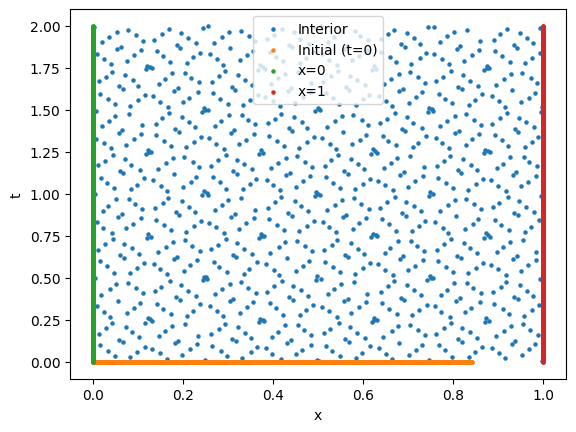

In [112]:
domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

def u_0(x):
    return torch.sin(x)

def v_0(x):
    return torch.cos(x)
    
def get_interior(data):
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

def get_BC(data):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    # x = 0
    data_0 = data.clone()
    data_0[:,0] = domain[0][0]

    # x = L
    data_L = data.clone()
    data_L[:,0] = domain[0][1]

    return data_0, data_L

def get_initial(data):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = u_0(x)
    u_t = v_0(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)
    u_t = torch.stack((u_t, torch.zeros_like(u_t)), dim=1)

    return u, u_t


# plotting
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data)
ic, _ = get_initial(data)
bc_0, bc_L = get_BC(data)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(ic[:,0], ic[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [113]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)
E_predictor_model = NN(input_dim = 1, output_dim = 1, layers = 4, neurons = 20)

In [114]:
# interior_data = get_interior(sobol_engine, 10)

def get_interior_residual(u_model, E_model, points):
    points.requires_grad = True

    u = u_model(points)
    grad_u = torch.autograd.grad(u.sum(), points, create_graph = True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]

    u_tt = torch.autograd.grad(u_t.sum(), points, create_graph=True)[0][:, 1]

    E = E_model(u_x.unsqueeze(1))
    E = E.squeeze() * u_x

    interior_residual = u_tt - torch.autograd.grad((E * u_t.unsqueeze(1)).sum(), points, create_graph=True)[0][:, 0]
    return interior_residual

interior_data = get_interior(next(iter(train_dataloader))) 
get_interior_residual(u_predictor_model, E_predictor_model, interior_data)

tensor([-0.0006, -0.0049,  0.0016, -0.0040, -0.0022, -0.0008, -0.0026, -0.0013,
        -0.0042, -0.0041, -0.0021, -0.0039, -0.0018,  0.0002, -0.0036, -0.0034,
        -0.0009, -0.0032, -0.0020, -0.0034, -0.0049, -0.0002, -0.0034, -0.0021,
        -0.0042, -0.0022, -0.0035,  0.0016, -0.0030, -0.0041, -0.0002, -0.0043],
       grad_fn=<SubBackward0>)

In [115]:
def get_IC_residue(u_model, u_0, v_0, points):

    u_0_data = points[0].clone().detach().requires_grad_(True) # u at t = 0
    u_t_data = points[1].clone().detach().requires_grad_(True) # u at t = 0

    u = u_model(u_0_data) 
    ic_1_residue = u - u_0(u_0_data[:, 0].unsqueeze(1))

    u_t = torch.autograd.grad(u.sum(), u_0_data, create_graph=True)[0][:, 1]
    ic_2_residue = u_t.unsqueeze(1) - v_0(u_t_data[:, 0].unsqueeze(1))

    return ic_1_residue, ic_2_residue

IC_data = get_initial(next(iter(train_dataloader))) # u, u_t (exact at t = 0)
# get_IC_residue(u_predictor_model, u_0, v_0, IC_data)

In [116]:
def get_BC_residue(u_model, points):
    return u_model(points[0]),  u_model(points[1])

BC_data = get_BC(next(iter(train_dataloader))) # t at u = 0 and t at u = L
# get_BC_residue(u_predictor_model, BC_data)

In [117]:
def grad_norm(loss, models):
    if not isinstance(models, list):
        models = [models]

    params = []
    for m in models:
        params += list(m.parameters())

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        allow_unused=True
    )

    norm = 0.0
    for g in grads:
        if g is not None:
            norm += torch.sum(g**2)
    return torch.sqrt(norm)

In [118]:
EPOCHS = 50


optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()) + 
    list(E_predictor_model.parameters()),
    lr=1e-3
)

epoch_loss_track = []
epoch_loss_track_test = []
residue_tracker = {}
grad_tracker = {
    "pde": [],
    "ic": [],
    "bc": []
}

for epoch in range(EPOCHS):
    residue_tracker[epoch] = []
    epoch_loss = 0
    epoch_loss_test = 0
    
    epoch_loss_PDE = 0
    epoch_loss_IC = 0
    epoch_loss_BC = 0

    g_pde_epoch = 0
    g_ic_epoch = 0
    g_bc_epoch = 0

    for train_data in train_dataloader:
        u_predictor_model.train()
        E_predictor_model.train()

        optimizer.zero_grad()
        interior_data = get_interior(train_data) 
        IC_data       = get_initial(train_data) # u, u_t (exact at t = 0)
        BC_data       = get_BC(train_data) # t at u = 0 and t at u = L


        interior_residue  = get_interior_residual(u_predictor_model, E_predictor_model, interior_data)
        IC_residue        = get_IC_residue(u_predictor_model, u_0, v_0, IC_data)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        # gradient mismatach
        models = [u_predictor_model, E_predictor_model]
        g_pde = grad_norm(loss_pde, models)
        g_ic  = grad_norm(loss_ic, models)
        g_bc  = grad_norm(loss_bc, models)

        g_pde_epoch += g_pde
        g_ic_epoch  += g_ic
        g_bc_epoch  += g_bc

        # total of iniduvidual residue
        epoch_loss_PDE += loss_pde
        epoch_loss_IC += loss_ic
        epoch_loss_BC += loss_bc

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss += loss
        loss.backward()
        optimizer.step()

        grad_tracker["pde"].append(g_pde.item())
        grad_tracker["ic"].append(g_ic.item())
        grad_tracker["bc"].append(g_bc.item())

    grad_tracker["pde"].append((g_pde_epoch / len(train_dataloader)).item())
    grad_tracker["ic"].append((g_ic_epoch / len(train_dataloader)).item())
    grad_tracker["bc"].append((g_bc_epoch / len(train_dataloader)).item())

    residue_tracker[epoch].extend((epoch_loss_PDE.item()/len(train_dataloader), 
                                   epoch_loss_IC.item()/len(train_dataloader), 
                                   epoch_loss_BC.item()/len(train_dataloader)))

    for test_data in test_dataloader:
        
        u_predictor_model.eval()
        E_predictor_model.eval()

        interior_data = get_interior(test_data) 
        IC_data       = get_initial(test_data) # u, u_t (exact at t = 0)
        BC_data       = get_BC(test_data) # t at u = 0 and t at u = L


        interior_residue  = get_interior_residual(u_predictor_model, E_predictor_model, interior_data)
        IC_residue        = get_IC_residue(u_predictor_model, u_0, v_0, IC_data)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data)


        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (BC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (IC_residue[1]**2))

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss_test += loss


    epoch_loss = epoch_loss / len(train_dataloader)
    epoch_loss_track.append(epoch_loss.item())

    epoch_loss_test = epoch_loss_test / len(test_dataloader)
    epoch_loss_track_test.append(epoch_loss_test.item())


    if (epoch % 10 == 0) or (epoch == EPOCHS-1):
        print(f"EPOCH: {epoch} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")

EPOCH: 0 | train loss: 0.6216 | test loss: 0.4846
EPOCH: 10 | train loss: 0.2176 | test loss: 0.1982
EPOCH: 20 | train loss: 0.1681 | test loss: 0.1799
EPOCH: 30 | train loss: 0.1629 | test loss: 0.1575
EPOCH: 40 | train loss: 0.1836 | test loss: 0.1626
EPOCH: 49 | train loss: 0.2142 | test loss: 0.1798


mean ratio pde/ic (first 20 iters): 0.0051
mean ratio pde/bc (first 20 iters): 0.0147


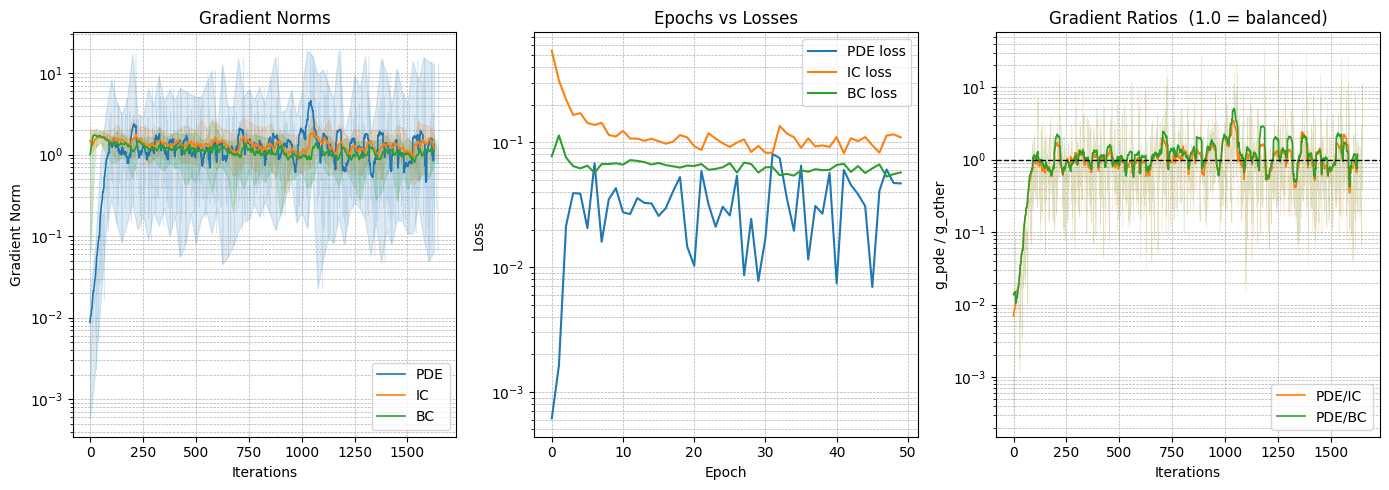

In [119]:
def smooth(x, w):
        return np.convolve(x, np.ones(w)/w, mode='valid')

def bounds(tracker, window):
    maxs, mins = [], []
    for i in range(len(tracker) // window):
        segment = tracker[i * window : (i + 1) * window]
        maxs.append(max(segment))
        mins.append(min(segment))
    return maxs, mins

def plot_gradients_and_losses(grad_tracker, residue_tracker, window=25):

    pde_maxs, pde_mins = bounds(grad_tracker["pde"], window)
    ic_maxs,  ic_mins  = bounds(grad_tracker["ic"],  window)
    bc_maxs,  bc_mins  = bounds(grad_tracker["bc"],  window)

    band_x = np.arange(len(pde_maxs)) * window

    pde_loss = [v[0] for v in residue_tracker.values()]
    ic_loss  = [v[1] for v in residue_tracker.values()]
    bc_loss  = [v[2] for v in residue_tracker.values()]

    g_pde = grad_tracker["pde"]
    g_ic  = grad_tracker["ic"]
    g_bc  = grad_tracker["bc"]

    ratio_ic = [p / (ic + 1e-8) for ic, p in zip(g_ic, g_pde)]
    ratio_bc = [p / (bc + 1e-8) for bc, p in zip(g_bc, g_pde)]

    print(f"mean ratio pde/ic (first 20 iters): {sum(ratio_ic[:20])/20:.4f}")
    print(f"mean ratio pde/bc (first 20 iters): {sum(ratio_bc[:20])/20:.4f}")

    plt.figure(figsize=(14, 5))

    # Plot 1: grad
    plt.subplot(1, 3, 1)

    s_x = np.arange(len(smooth(g_pde, window)))
    plt.plot(g_pde, alpha=0.15, linewidth=0.5, color="C0")
    plt.plot(g_ic,  alpha=0.15, linewidth=0.5, color="C1")
    plt.plot(g_bc,  alpha=0.15, linewidth=0.5, color="C2")
    plt.plot(s_x, smooth(g_pde, window), color="C0", linewidth=1.2, label="PDE")
    plt.plot(s_x, smooth(g_ic,  window), color="C1", linewidth=1.2, label="IC")
    plt.plot(s_x, smooth(g_bc,  window), color="C2", linewidth=1.2, label="BC")

    # FIX: fill_between instead of flat axhline — shows evolution over time
    plt.fill_between(band_x, pde_mins, pde_maxs, alpha=0.15, color="C0")
    plt.fill_between(band_x, ic_mins,  ic_maxs,  alpha=0.15, color="C1")
    plt.fill_between(band_x, bc_mins,  bc_maxs,  alpha=0.15, color="C2")

    plt.yscale("log")
    plt.title("Gradient Norms")
    plt.xlabel("Iterations")
    plt.ylabel("Gradient Norm")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    # Plot 2: losses
    plt.subplot(1, 3, 2)
    plt.plot(pde_loss, label="PDE loss")
    plt.plot(ic_loss,  label="IC loss")
    plt.plot(bc_loss,  label="BC loss")
    plt.yscale("log")   # FIX: log scale so smaller losses are visible
    plt.title("Epochs vs Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    # Plot 3: ratios
    plt.subplot(1, 3, 3)
    s_x = np.arange(len(smooth(ratio_ic, window)))
    plt.plot(ratio_ic, alpha=0.15, linewidth=0.5, color="C1")
    plt.plot(ratio_bc, alpha=0.15, linewidth=0.5, color="C2")
    plt.plot(s_x, smooth(ratio_ic, window), color="C1", linewidth=1.2, label="PDE/IC")  # FIX: label matches corrected ratio
    plt.plot(s_x, smooth(ratio_bc, window), color="C2", linewidth=1.2, label="PDE/BC")
    plt.axhline(1.0, linestyle="--", color="black", linewidth=1.0)
    plt.yscale("log")
    plt.title("Gradient Ratios  (1.0 = balanced)")
    plt.xlabel("Iterations")
    plt.ylabel("g_pde / g_other")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_gradients_and_losses(grad_tracker, residue_tracker, window=25)

Initial losses — PDE: 9.9047e-06  IC: 6.7508e-01  BC: 6.6206e-03


In [254]:
EPOCHS = 100


u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20, activation = 'sin')
E_predictor_model = NN(input_dim = 1, output_dim = 1, layers = 4, neurons = 20, activation = "sin")


lambda_pde = 1
lambda_ic = 1
lambda_bc = 1

optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()) + 
    list(E_predictor_model.parameters()),
    lr=1e-4
)

epoch_loss_track = []
epoch_loss_track_test = []
residue_tracker = {}
grad_tracker = {
    "pde": [],
    "ic": [],
    "bc": []
}

lambda_tracker = {"pde": [], "ic": [], "bc": []}

for epoch in range(EPOCHS):
    residue_tracker[epoch] = []
    epoch_loss = 0
    epoch_loss_test = 0
    
    epoch_loss_PDE = 0
    epoch_loss_IC = 0
    epoch_loss_BC = 0

    g_pde_epoch = 0
    g_ic_epoch = 0
    g_bc_epoch = 0

    g_pdes = []
    g_ics = []
    g_bcs = []

    for train_data in train_dataloader:

        u_predictor_model.train()
        E_predictor_model.train()

        optimizer.zero_grad()
        interior_data = get_interior(train_data) 
        IC_data       = get_initial(train_data) # u, u_t (exact at t = 0)
        BC_data       = get_BC(train_data) # t at u = 0 and t at u = L


        interior_residue  = get_interior_residual(u_predictor_model, E_predictor_model, interior_data)
        IC_residue        = get_IC_residue(u_predictor_model, u_0, v_0, IC_data)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))


        # gradient mismatach
        models = [u_predictor_model, E_predictor_model]
        g_pde = grad_norm(loss_pde, models)
        g_ic  = grad_norm(loss_ic, models)
        g_bc  = grad_norm(loss_bc, models)
        

        g_pdes.append(g_pde)
        g_ics.append(g_ic)
        g_bcs.append(g_bc)

        g_pde_epoch += g_pde
        g_ic_epoch  += g_ic
        g_bc_epoch  += g_bc


        # total of iniduvidual residue
        epoch_loss_PDE += loss_pde
        epoch_loss_IC += loss_ic
        epoch_loss_BC += loss_bc

        # total
        # lambda_pde, lambda_ic, lambda_bc = 1, 1, 1
        loss = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc

        
        epoch_loss += loss
        loss.backward()
        optimizer.step()

        grad_tracker["pde"].append(g_pde.item())
        grad_tracker["ic"].append(g_ic.item())
        grad_tracker["bc"].append(g_bc.item())

    g_pde_mean = np.mean([g.item() for g in g_pdes])
    g_ic_mean  = np.mean([g.item() for g in g_ics])
    g_bc_mean  = np.mean([g.item() for g in g_bcs])
    g_max_mean = max(g_pde_mean, g_ic_mean, g_bc_mean)

    beta = 0.9
    # lambda_pde = beta * lambda_pde + (1 - beta) * (g_max_mean / (g_pde_mean + 1e-8))
    lambda_ic  = beta * lambda_ic  + (1 - beta) * (g_max_mean / (g_ic_mean  + 1e-8))
    lambda_bc  = beta * lambda_bc  + (1 - beta) * (g_max_mean / (g_bc_mean  + 1e-8))

    lambda_pde = float(np.clip(lambda_pde, 0.05, 100.0))
    lambda_ic  = float(np.clip(lambda_ic,  0.05, 100.0))
    lambda_bc  = float(np.clip(lambda_bc,  0.05, 100.0))

    lambda_tracker["pde"].append(lambda_pde)
    lambda_tracker["ic"].append(lambda_ic)
    lambda_tracker["bc"].append(lambda_bc)


    residue_tracker[epoch].extend((epoch_loss_PDE.item()/len(train_dataloader), 
                                   epoch_loss_IC.item()/len(train_dataloader), 
                                   epoch_loss_BC.item()/len(train_dataloader)))

    for test_data in test_dataloader:
        
        u_predictor_model.eval()
        E_predictor_model.eval()

        interior_data = get_interior(test_data) 
        IC_data       = get_initial(test_data) # u, u_t (exact at t = 0)
        BC_data       = get_BC(test_data) # t at u = 0 and t at u = L


        interior_residue  = get_interior_residual(u_predictor_model, E_predictor_model, interior_data)
        IC_residue        = get_IC_residue(u_predictor_model, u_0, v_0, IC_data)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data)


        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        # total
        loss = (lambda_pde * loss_pde) + (lambda_ic * loss_ic) + (lambda_bc * loss_bc)
        epoch_loss_test += loss


    epoch_loss = epoch_loss / len(train_dataloader)
    epoch_loss_track.append(epoch_loss.item())

    epoch_loss_test = epoch_loss_test / len(test_dataloader)
    epoch_loss_track_test.append(epoch_loss_test.item())


    # if (epoch % 10 == 0) or (epoch == EPOCHS-1):
    #     print(f"EPOCH: {epoch} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")

    if (epoch % 10 == 0) or (epoch == EPOCHS - 1):
        print(
            f"EPOCH {epoch} | "
            f"λ_pde={lambda_pde:.2f}  λ_ic={lambda_ic:.2f}  λ_bc={lambda_bc:.2f} | "
            f"g_pde={grad_tracker['pde'][-1]:.4f}  "
            f"g_ic={grad_tracker['ic'][-1]:.4f}  "
            f"g_bc={grad_tracker['bc'][-1]:.4f}"
        )
        print(f"-> PDE: {lambda_pde * g_pde} | IC: {lambda_ic * g_ic} | BC: {lambda_bc * g_bc}")

EPOCH 0 | λ_pde=1.00  λ_ic=1.00  λ_bc=1.13 | g_pde=0.0014  g_ic=1.8001  g_bc=0.4911
-> PDE: 0.001412546494975686 | IC: 1.8001164197921753 | BC: 0.5549464225769043
EPOCH 10 | λ_pde=1.00  λ_ic=1.00  λ_bc=2.14 | g_pde=0.2492  g_ic=2.0425  g_bc=0.9598
-> PDE: 0.2491997629404068 | IC: 2.042475700378418 | BC: 2.0516836643218994
EPOCH 20 | λ_pde=1.00  λ_ic=1.00  λ_bc=2.18 | g_pde=1.8323  g_ic=1.9774  g_bc=0.8955
-> PDE: 1.8323369026184082 | IC: 1.977420449256897 | BC: 1.950613260269165
EPOCH 30 | λ_pde=1.00  λ_ic=1.00  λ_bc=2.28 | g_pde=4.2125  g_ic=2.3823  g_bc=0.9752
-> PDE: 4.2124924659729 | IC: 2.382314682006836 | BC: 2.2266056537628174
EPOCH 40 | λ_pde=1.00  λ_ic=1.00  λ_bc=2.42 | g_pde=0.9630  g_ic=2.2211  g_bc=0.3349
-> PDE: 0.9630293250083923 | IC: 2.2211477756500244 | BC: 0.8098695278167725
EPOCH 50 | λ_pde=1.00  λ_ic=1.00  λ_bc=2.53 | g_pde=1.2887  g_ic=1.8627  g_bc=0.2537
-> PDE: 1.2887496948242188 | IC: 1.8627320528030396 | BC: 0.6410568952560425
EPOCH 60 | λ_pde=1.00  λ_ic=1.00  

In [255]:
lambda_tracker['pde'][-1], lambda_tracker['ic'][-1], lambda_tracker['bc'][-1]

(1.0, 1.0091082166389453, 3.3685202794827265)

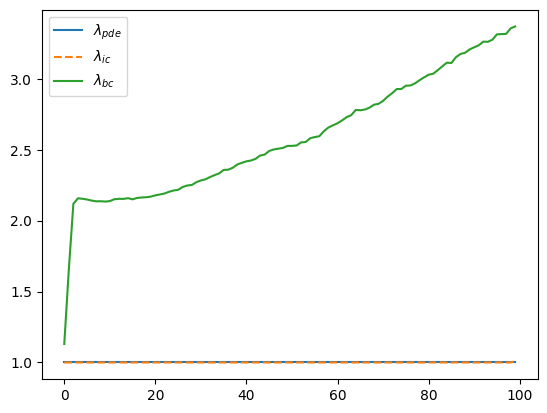

In [256]:
plt.plot(lambda_tracker['pde'], label = "$\lambda_{pde}$")
plt.plot(lambda_tracker['ic'], label = "$\lambda_{ic}$", linestyle = "--")
plt.plot(lambda_tracker['bc'], label = "$\lambda_{bc}$")
plt.legend()

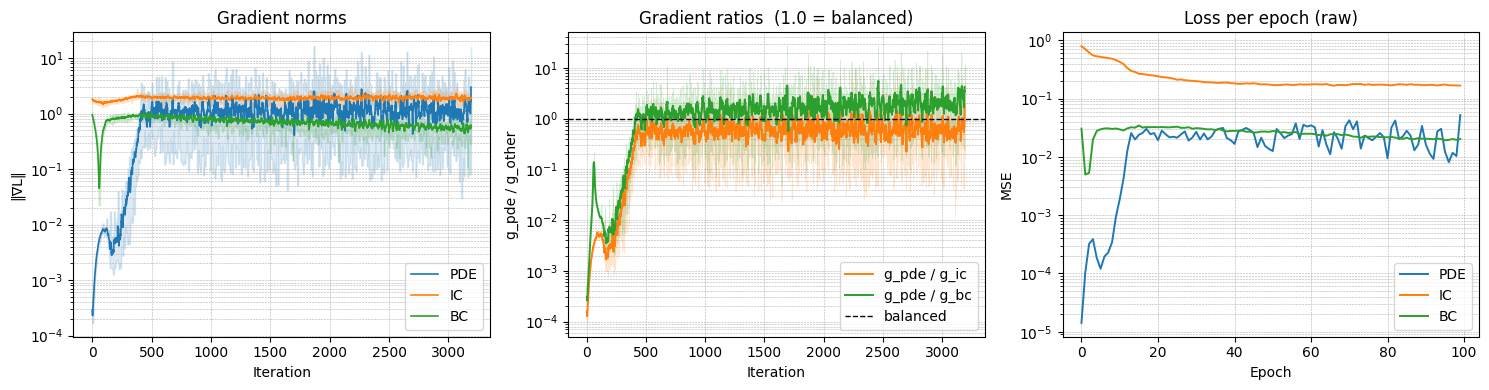

Mean ratio  g_pde/g_ic : 0.5682  (last 20%: 0.6909)
Mean ratio  g_pde/g_bc : 1.5610  (last 20%: 2.2158)
Grad norm ranges — PDE: [0.000, 16.378]  IC: [0.802, 3.062]  BC: [0.022, 1.434]


In [257]:
plot_gradients_and_losses(grad_tracker, residue_tracker, window=10)

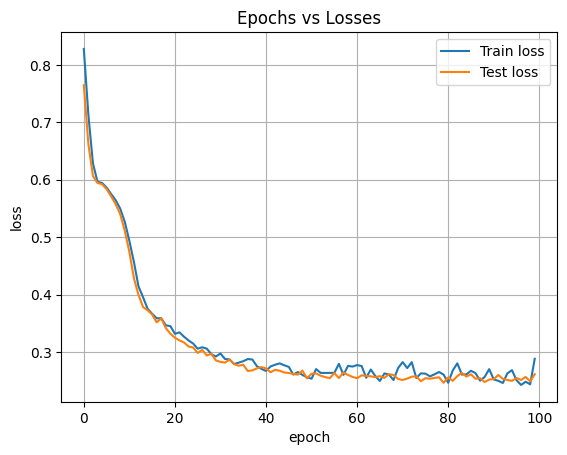

In [258]:
plt.plot(epoch_loss_track, label = "Train loss")
plt.plot(epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

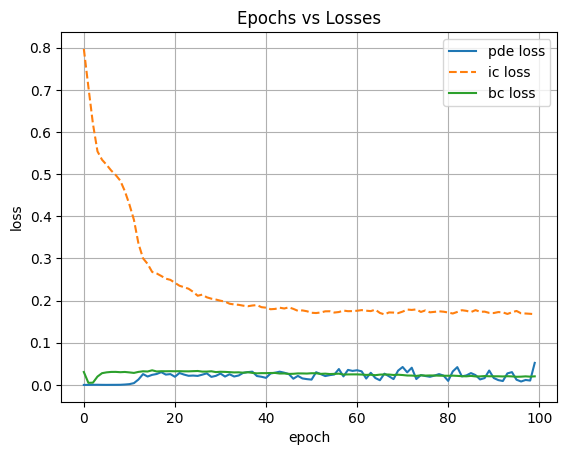

In [259]:
pde_loss = [v[0] for k, v in residue_tracker.items()]
ic_loss = [v[1] for k, v in residue_tracker.items()]
bc_loss = [v[2] for k, v in residue_tracker.items()]

plt.plot(pde_loss, label = "pde loss")
plt.plot(ic_loss, label = "ic loss", linestyle = "--")
plt.plot(bc_loss, label = "bc loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

# plt.yscale('log')

plt.show()

In [260]:
x_s = torch.linspace(domain[0][0], domain[0][1], 100)
t_s = torch.linspace(domain[1][0], domain[1][1], 100)

X, T = torch.meshgrid(x_s, t_s, indexing='ij')

points = torch.stack((X.flatten(), T.flatten()), dim=1)
points = points.clone().detach().requires_grad_(True)

u = u_predictor_model(points)

grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]

u_x = grad_u[:, 0]

E = E_predictor_model(u_x.unsqueeze(1))

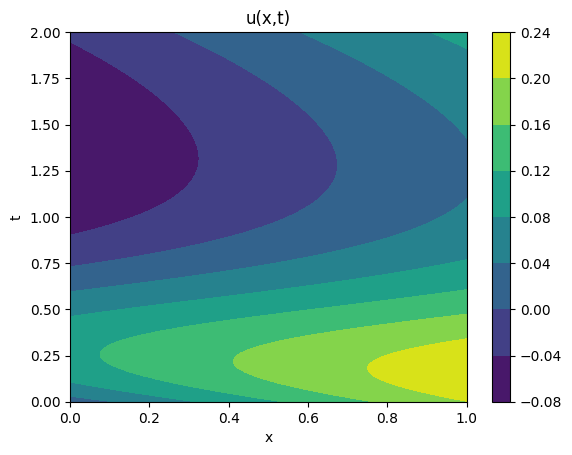

In [261]:
U = u.reshape(100, 100).detach().numpy()
plt.contourf(X.detach().numpy(), T.detach().numpy(), U)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("u(x,t)")
plt.show()

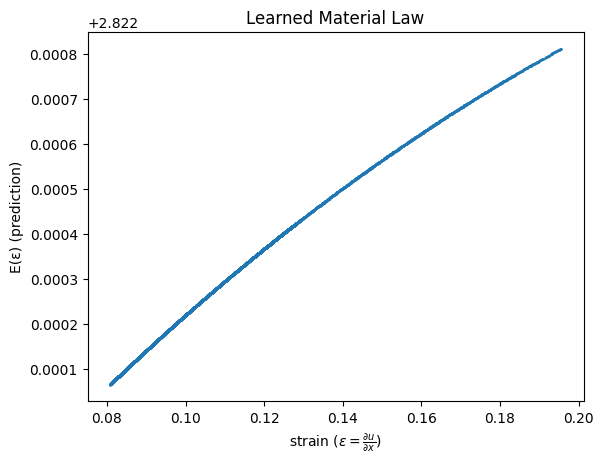

In [262]:
epsilon = u_x.detach().numpy()
E_vals  = E.detach().numpy()

plt.scatter(epsilon, E_vals, s=1)
plt.xlabel(r"strain ($\varepsilon = \frac{\partial u}{\partial x}$)")
plt.ylabel("E(ε) (prediction)")
plt.title("Learned Material Law")
plt.show()

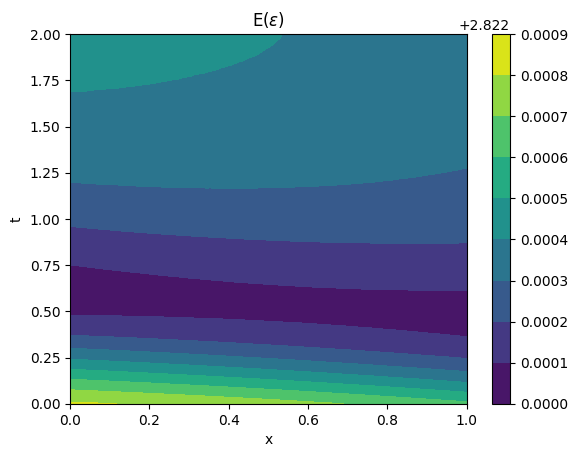

In [263]:
E_reshape = E.reshape(100, 100).detach().numpy()

plt.contourf(X.detach().numpy(), T.detach().numpy(), E_reshape)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("E($\epsilon$)")
plt.show()